Button(description='Next Generation', icon='check', style=ButtonStyle(), tooltip='Next Generation')

Best solution so far:
10 f(x, y) =  21.570528187883692


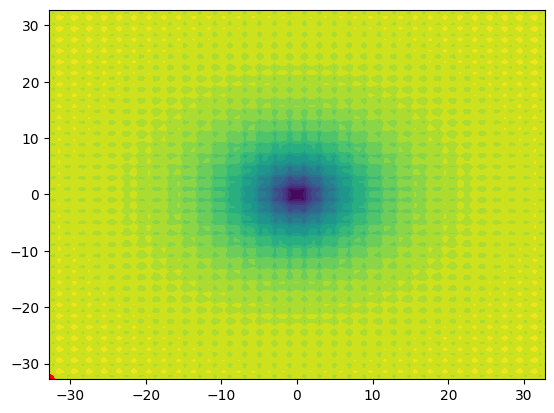

In [ ]:
import ipywidgets as widgets
import math
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from IPython import display as display

from functools import cmp_to_key

# Chromosomes are 32 bits long (16 bits per dimension for 2D)
L_chromosome = 32
N_chains = 2 ** L_chromosome
# Lower and upper limits of search space for 2D Ackley
a = -32.768
b = 32.768
crossover_point = int(L_chromosome / 2)

def create_button():
    button = widgets.Button(
        description='Next Generation',
        disabled=False,
        button_style='',  # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Next Generation',
        icon='check'  # (FontAwesome names without the `fa-` prefix)
    )
    return button

def ackley(x, y):
    term1 = -0.2 * math.sqrt(0.5 * (x**2 + y**2))
    term2 = 0.5 * (math.cos(2 * math.pi * x) + math.cos(2 * math.pi * y))
    return -20 * math.exp(term1) - math.exp(term2) + 20 + math.e

def decode_chromosome(chromosome):
    global L_chromosome, N_chains, a, b
    x_value = a + (b - a) * int(''.join(map(str, chromosome[:16])), 2) / (N_chains - 1)
    y_value = a + (b - a) * int(''.join(map(str, chromosome[16:])), 2) / (N_chains - 1)
    return x_value, y_value

# Number of chromosomes
N_chromosomes = 10
# Probability of mutation
prob_m = 0.01

F0 = []
fitness_values = []

for i in range(0, N_chromosomes):
    F0.append([random.randint(0, 1) for _ in range(L_chromosome)])
    fitness_values.append(0)

def f(x):
    x_value, y_value = decode_chromosome(x)
    return ackley(x_value, y_value)

def evaluate_chromosomes():
    global F0

    for p in range(N_chromosomes):
        fitness_values[p] = f(F0[p])

def compare_chromosomes(chromosome1, chromosome2):
    x1, y1 = decode_chromosome(chromosome1)
    x2, y2 = decode_chromosome(chromosome2)
    fvc1 = ackley(x1, y1)
    fvc2 = ackley(x2, y2)
    if fvc1 > fvc2:
        return 1
    elif fvc1 == fvc2:
        return 0
    else:  # fvc1 < fvc2
        return -1

suma = float(N_chromosomes * (N_chromosomes + 1)) / 2.

Lwheel = N_chromosomes * 10

def create_wheel():
    global F0, fitness_values

    maxv = max(fitness_values)
    acc = 0
    for p in range(N_chromosomes):
        acc += maxv - fitness_values[p]
    fraction = []
    for p in range(N_chromosomes):
        fraction.append(float(maxv - fitness_values[p]) / acc)
        if fraction[-1] <= 1.0 / Lwheel:
            fraction[-1] = 1.0 / Lwheel
    fraction[0] -= (sum(fraction) - 1.0) / 2
    fraction[1] -= (sum(fraction) - 1.0) / 2
    wheel = []
    pc = 0
    for f in fraction:
        Np = int(f * Lwheel)
        for i in range(Np):
            wheel.append(pc)
        pc += 1
    return wheel

F1 = F0[:]
n = 0

def nextgeneration(b):
    global n
    display.clear_output(wait=True)
    display.display(button)
    F0.sort(key=cmp_to_key(compare_chromosomes))
    print("Best solution so far:")
    n += 1
    x, y = decode_chromosome(F0[0])
    print(n, "f(x, y) = ", ackley(x, y))
    F1[0] = F0[0]
    F1[1] = F0[1]
    roulette = create_wheel()
    for i in range(0, int((N_chromosomes - 2) / 2)):
        p1 = random.choice(roulette)
        p2 = random.choice(roulette)
        o1 = F0[p1][:crossover_point] + F0[p2][crossover_point:]
        o2 = F0[p2][:crossover_point] + F0[p1][crossover_point:]
        if random.random() < prob_m:
            o1[int(round(random.random() * (L_chromosome - 1)))] ^= 1

        if random.random() < prob_m:
            o2[int(round(random.random() * (L_chromosome - 1)))] ^= 1

        F1[2 + 2 * i] = o1
        F1[3 + 2 * i] = o2
    graph_population(F1)
    F0[:] = F1[:]

xmax = 400
ymax = 400

xo = 200
yo = 200

s = 10

N = 100

global_fig = plt.figure()
ax = plt.axes()

def graph_f():
    x_values = np.linspace(a, b, N)
    y_values = np.linspace(a, b, N)
    X, Y = np.meshgrid(x_values, y_values)
    Z = np.array([[ackley(x, y) for x, y in zip(x_row, y_row)] for x_row, y_row in zip(X, Y)])
    plt.contourf(X, Y, Z, levels=20, cmap='viridis')

def graph_population(F):
    x, y = zip(*[decode_chromosome(chromosome) for chromosome in F])
    graph_f()
    plt.scatter(x, y, c='r', marker='o', label='Population')

button = create_button()
button.on_click(nextgeneration)
display.display(button)

x, y = zip(*[decode_chromosome(chromosome) for chromosome in F0])
graph_f()
plt.scatter(x, y, c='r', marker='o', label='Population')
F0.sort(key=cmp_to_key(compare_chromosomes))
evaluate_chromosomes()
plt.legend()
plt.show()


In [13]:
import ipywidgets as widgets
from IPython.display import display 

def create_button():
  button = widgets.Button(
    description='Next Generation',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Next Generation',
    icon='check' # (FontAwesome names without the `fa-` prefix)
  )
  return button

# Create the button using the create_button function
button = create_button()
display(button)

Button(description='Next Generation', icon='check', style=ButtonStyle(), tooltip='Next Generation')

In [4]:
# random.choices(indexes,weights=fitness_values)
# fitness=[]
# maxfv=max(fitness_values)
# for fv in fitness_values:
#   fitness.append(maxfv-fv+1)
# fitness

Button(description='Next Generation', icon='check', style=ButtonStyle(), tooltip='Next Generation')

Best solution so far:
2 f(x, y) =  21.570544752226116


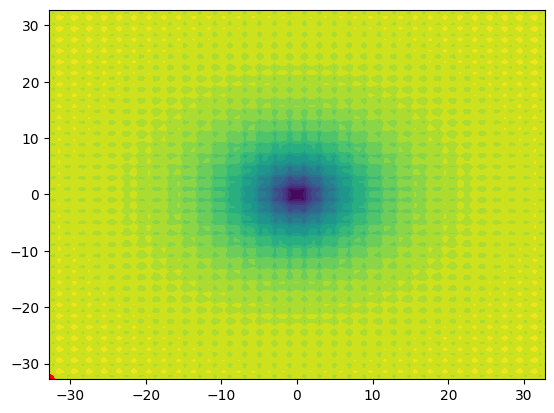

In [3]:
import ipywidgets as widgets
import math
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from IPython import display as display

from functools import cmp_to_key

# Chromosomes are 32 bits long (16 bits per dimension for 2D)
L_chromosome = 32
N_chains = 2 ** L_chromosome
# Lower and upper limits of search space for 2D Ackley
a = -32.768
b = 32.768
crossover_point = int(L_chromosome / 2)

def create_button():
    button = widgets.Button(
        description='Next Generation',
        disabled=False,
        button_style='',  # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Next Generation',
        icon='check'  # (FontAwesome names without the `fa-` prefix)
    )
    return button

def ackley(x, y):
    term1 = -0.2 * math.sqrt(0.5 * (x**2 + y**2))
    term2 = 0.5 * (math.cos(2 * math.pi * x) + math.cos(2 * math.pi * y))
    return -20 * math.exp(term1) - math.exp(term2) + 20 + math.e

def decode_chromosome(chromosome):
    global L_chromosome, N_chains, a, b
    x_value = a + (b - a) * int(''.join(map(str, chromosome[:16])), 2) / (N_chains - 1)
    y_value = a + (b - a) * int(''.join(map(str, chromosome[16:])), 2) / (N_chains - 1)
    return x_value, y_value

# Number of chromosomes
N_chromosomes = 10
# Probability of mutation
prob_m = 0.01

F0 = []
fitness_values = []

for i in range(0, N_chromosomes):
    F0.append([random.randint(0, 1) for _ in range(L_chromosome)])
    fitness_values.append(0)

def evaluate_chromosomes():
    global F0

    for p in range(N_chromosomes):
        x, y = decode_chromosome(F0[p])
        fitness_values[p] = ackley(x, y)

def compare_chromosomes(chromosome1, chromosome2):
    x1, y1 = decode_chromosome(chromosome1)
    x2, y2 = decode_chromosome(chromosome2)
    fvc1 = ackley(x1, y1)
    fvc2 = ackley(x2, y2)
    if fvc1 > fvc2:
        return 1
    elif fvc1 == fvc2:
        return 0
    else:  # fvc1 < fvc2
        return -1

suma = float(N_chromosomes * (N_chromosomes + 1)) / 2.

Lwheel = N_chromosomes * 10

def create_wheel():
    global F0, fitness_values

    maxv = max(fitness_values)
    acc = 0
    for p in range(N_chromosomes):
        acc += maxv - fitness_values[p]
    fraction = []
    for p in range(N_chromosomes):
        fraction.append(float(maxv - fitness_values[p]) / acc)
        if fraction[-1] <= 1.0 / Lwheel:
            fraction[-1] = 1.0 / Lwheel
    fraction[0] -= (sum(fraction) - 1.0) / 2
    fraction[1] -= (sum(fraction) - 1.0) / 2
    wheel = []
    pc = 0
    for f in fraction:
        Np = int(f * Lwheel)
        for i in range(Np):
            wheel.append(pc)
        pc += 1
    return wheel

F1 = F0[:]
n = 0

def nextgeneration(b):
    global n
    display.clear_output(wait=True)
    display.display(button)
    F0.sort(key=cmp_to_key(compare_chromosomes))
    print("Best solution so far:")
    n += 1
    x, y = decode_chromosome(F0[0])
    print(n, "f(x, y) = ", ackley(x, y))
    F1[0] = F0[0]
    F1[1] = F0[1]
    roulette = create_wheel()
    for i in range(0, int((N_chromosomes - 2) / 2)):
        p1 = random.choice(roulette)
        p2 = random.choice(roulette)
        o1 = F0[p1][:crossover_point] + F0[p2][crossover_point:]
        o2 = F0[p2][:crossover_point] + F0[p1][crossover_point:]
        if random.random() < prob_m:
            o1[int(round(random.random() * (L_chromosome - 1)))] ^= 1
        if random.random() < prob_m:
            o2[int(round(random.random() * (L_chromosome - 1)))] ^= 1

        F1[2 + 2 * i] = o1
        F1[3 + 2 * i] = o2
    graph_population(F1)
    F0[:] = F1[:]

xmax = 400
ymax = 400

xo = 200
yo = 200

s = 10

N = 100

global_fig = plt.figure()
ax = plt.axes()

def graph_f():
    x_values = np.linspace(a, b, N)
    y_values = np.linspace(a, b, N)
    X, Y = np.meshgrid(x_values, y_values)
    Z = np.array([[ackley(x, y) for x, y in zip(x_row, y_row)] for x_row, y_row in zip(X, Y)])
    plt.contourf(X, Y, Z, levels=20, cmap='viridis')

def graph_population(F):
    x, y = zip(*[decode_chromosome(chromosome) for chromosome in F])
    graph_f()
    plt.scatter(x, y, c='r', marker='o', label='Population')

button = create_button()
button.on_click(nextgeneration)
display.display(button)

x, y = zip(*[decode_chromosome(chromosome) for chromosome in F0])
graph_f()
plt.scatter(x, y, c='r', marker='o', label='Population')
F0.sort(key=cmp_to_key(compare_chromosomes))
evaluate_chromosomes()
plt.legend()
plt.show()
